<a href="https://colab.research.google.com/github/XTMay/LLM_AI_Agent/blob/main/Notebook/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

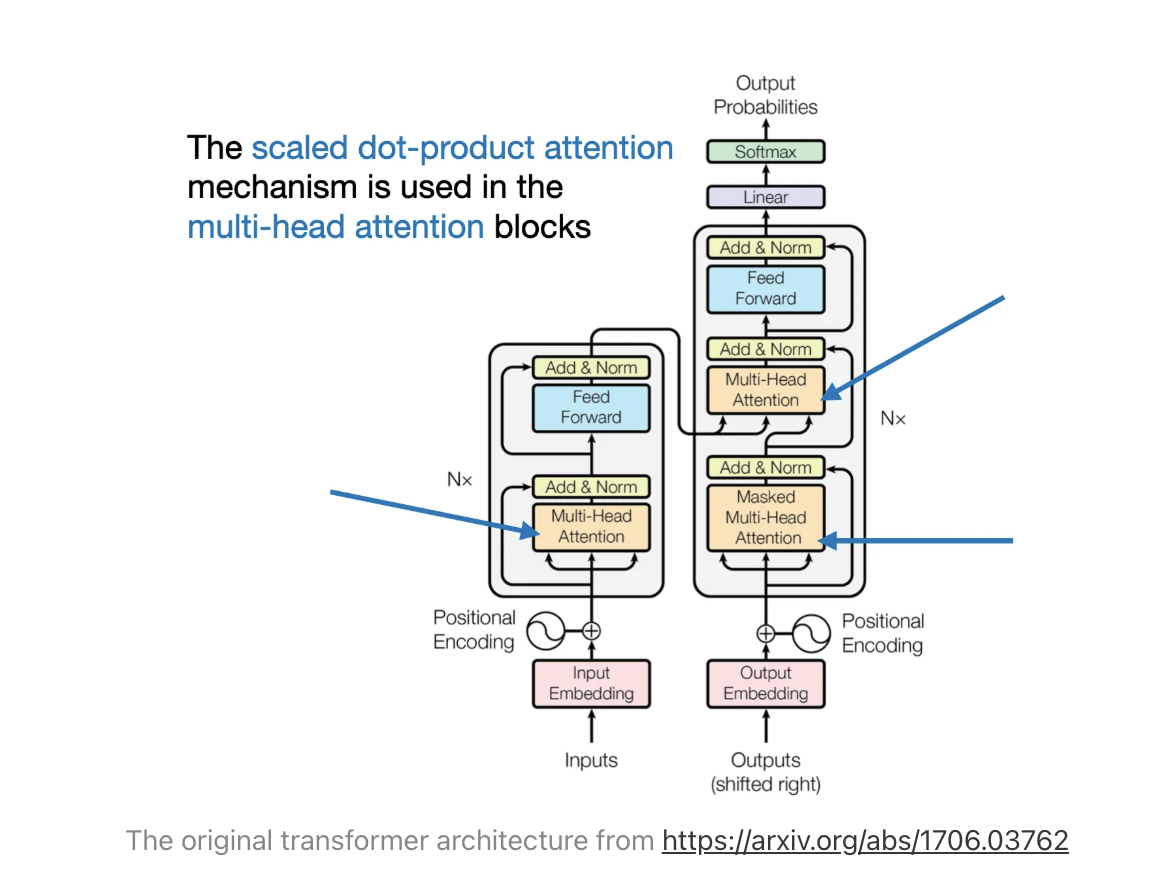

In [ ]:
sentence = "Life is short, eat dessert first"

In [ ]:
dc = {word: i for i, word in enumerate(sorted(sentence.replace(',', "").split(' ')))}
sentence_int = torch.tensor([dc[word] for word in sorted(sentence.replace(',', "").split(' '))])
print(sentence_int)

tensor([0, 1, 2, 3, 4, 5])


In [ ]:
vocab_size = 50000
torch.manual_seed(123)
embed = torch.nn.Embedding(vocab_size, 3)
embed

Embedding(50000, 3)

In [ ]:
embedded_sentence = embed(sentence_int).detach()
embedded_sentence

tensor([[ 0.3374, -0.1778, -0.3035],
        [-0.5880,  0.3486,  0.6603],
        [-0.2196, -0.3792,  0.7671],
        [-1.1925,  0.6984, -1.4097],
        [ 0.1794,  1.8951,  0.4954],
        [ 0.2692, -0.0770, -1.0205]])

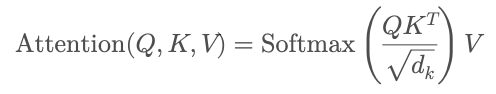

# Self Attention

In [ ]:
import torch
import torch.nn as nn

class SelfAttention(nn.Module):
  def __init__(self, d_in, d_out_kq, d_out_v):
    super().__init__()
    self.d_out_kq = d_out_kq

    self.W_query = nn.Parameter(torch.rand(d_in, d_out_kq))
    self.W_key = nn.Parameter(torch.rand(d_in, d_out_kq))
    self.W_value = nn.Parameter(torch.rand(d_in, d_out_v))

  def forward(self, x):
    keys = x @ self.W_key
    queries = x @ self.W_query
    values = x @ self.W_value

    attention_score = queries @ keys.T
    attention_weights = torch.softmax(
        attention_score / self.d_out_kq**0.5, dim=-1
    )

    context_vector = attention_weights @ values

    return context_vector

In [ ]:
torch.manual_seed(123)

In [ ]:
d_in, d_out_kq, d_out_v = 3, 2, 4

sa = SelfAttention(d_in, d_out_kq, d_out_v)
print(sa)

SelfAttention()


In [ ]:
torch.manual_seed(123)

# reduce d_out_v from 4 to 1, because we have 4 heads
d_in, d_out_kq, d_out_v = 3, 2, 4

sa = SelfAttention(d_in, d_out_kq, d_out_v)
print(sa(embedded_sentence))

tensor([[-0.1564,  0.1028, -0.0763, -0.0764],
        [ 0.1008,  0.4780,  0.2021,  0.3674],
        [ 0.0071,  0.3345,  0.0969,  0.1998],
        [-0.5296, -0.2799, -0.4107, -0.6006],
        [ 0.5313,  1.3607,  0.7891,  1.3110],
        [-0.3542, -0.1234, -0.2626, -0.3706]], grad_fn=<MmBackward0>)


# Muti-Head Attention

In [ ]:
class MultiHeadAttentionWrapper(nn.Module):
  def __init__(self, d_in, d_out_kq, d_out_v, num_heads):
    super().__init__()
    self.heads = nn.ModuleList(
        [
          SelfAttention(d_in, d_out_kq, d_out_v)
          for _ in range(num_heads)
        ]
    )
  def forward(self, x):
    return torch.cat([head(x) for head in self.heads], dim=-1)

In [ ]:
torch.manual_seed(123)

d_in, d_out_kq, d_out_v = 3, 2, 1
sa = SelfAttention(d_in, d_out_kq, d_out_v)

print(sa(embedded_sentence))

tensor([[-0.0185],
        [ 0.1180],
        [ 0.0668],
        [-0.1827],
        [ 0.4003],
        [-0.1103]], grad_fn=<MmBackward0>)


In [ ]:
torch.manual_seed(123)

block_size = embedded_sentence.shape[1]

mha = MultiHeadAttentionWrapper(
    d_in, d_out_kq, d_out_v, num_heads=3
)
context_vecs = mha(embedded_sentence)

print(context_vecs)

tensor([[-0.0185,  0.0170,  0.1999],
        [ 0.1180,  0.6949,  0.3157],
        [ 0.0668,  0.3534,  0.2322],
        [-0.1827, -0.2060, -0.2393],
        [ 0.4003,  1.7137,  1.3981],
        [-0.1103, -0.1609,  0.0079]], grad_fn=<CatBackward0>)


In [ ]:
block_size

3

# Causal Self Attention

In [ ]:
torch.manual_seed(123)

d_in, d_out_kq, d_out_v = 3, 2, 4

W_query = nn.Parameter(torch.rand(d_in, d_out_kq))
W_key = nn.Parameter(torch.rand(d_in, d_out_kq))
W_value = nn.Parameter(torch.rand(d_in, d_out_v))

x = embedded_sentence

keys = x @ W_key # 6 x 3, 3 x 2 -> 6 x 2
values = x @ W_value
queries = x @ W_query # 6 x 3, 3 x 2 -> 6 x 2

attn_scores = queries @ keys.T
print(attn_scores)
print(attn_scores.shape)

tensor([[ 0.0613, -0.1303, -0.0437,  0.1076, -0.3491,  0.1443],
        [-0.1510,  0.3216,  0.1112, -0.2787,  0.8626, -0.3597],
        [-0.0794,  0.1677,  0.0518, -0.1197,  0.4487, -0.1807],
        [ 0.4344, -0.9315, -0.3509,  0.9265, -2.5037,  1.0740],
        [-0.6004,  1.2903,  0.4991, -1.3374,  3.4707, -1.5023],
        [ 0.2432, -0.5191, -0.1851,  0.4730, -1.3934,  0.5869]],
       grad_fn=<MmBackward0>)
torch.Size([6, 6])


In [ ]:
atten_weights = torch.softmax(attn_scores / d_out_kq**0.5, dim=-1)
print(atten_weights)

tensor([[0.1772, 0.1547, 0.1645, 0.1831, 0.1326, 0.1879],
        [0.1347, 0.1881, 0.1621, 0.1231, 0.2758, 0.1162],
        [0.1505, 0.1793, 0.1651, 0.1463, 0.2187, 0.1401],
        [0.1973, 0.0751, 0.1132, 0.2794, 0.0247, 0.3102],
        [0.0386, 0.1470, 0.0840, 0.0229, 0.6870, 0.0204],
        [0.1965, 0.1146, 0.1452, 0.2312, 0.0618, 0.2506]],
       grad_fn=<SoftmaxBackward0>)


In [ ]:
block_size = attn_scores.shape[0]
block_size

6

In [ ]:
mask_simple = torch.tril(torch.ones(block_size, block_size))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [ ]:
masked_simple = atten_weights * mask_simple
print(masked_simple)

tensor([[0.1772, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1347, 0.1881, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1505, 0.1793, 0.1651, 0.0000, 0.0000, 0.0000],
        [0.1973, 0.0751, 0.1132, 0.2794, 0.0000, 0.0000],
        [0.0386, 0.1470, 0.0840, 0.0229, 0.6870, 0.0000],
        [0.1965, 0.1146, 0.1452, 0.2312, 0.0618, 0.2506]],
       grad_fn=<MulBackward0>)


# Transformer

## Encoder-Decoder

In [ ]:
import torch
import torch.nn as nn
import math


# ---------------------------
# 位置编码 (Positional Encoding)
# ---------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)   # 偶数位置
        pe[:, 1::2] = torch.cos(position * div_term)   # 奇数位置

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: [batch_size, seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :]
        return x


# ---------------------------
# 前馈网络 (Feed Forward)
# ---------------------------
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(FeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))


# ---------------------------
# 编码器层 (Encoder Layer)
# ---------------------------
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask=None):
        # Self-Attention
        attn_output, _ = self.self_attn(src, src, src, attn_mask=src_mask)
        src = self.norm1(src + self.dropout(attn_output))
        # Feed Forward
        ff_output = self.feed_forward(src)
        src = self.norm2(src + self.dropout(ff_output))
        return src


# ---------------------------
# 解码器层 (Decoder Layer)
# ---------------------------
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super(DecoderLayer, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout) # masked
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout) # encoder - decoder
        self.feed_forward = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, memory, tgt_mask=None, memory_mask=None):
        # Masked Self-Attention (未来 token 不可见)
        attn_output, _ = self.self_attn(tgt, tgt, tgt, attn_mask=tgt_mask)
        tgt = self.norm1(tgt + self.dropout(attn_output))

        # Cross-Attention
        attn_output, _ = self.cross_attn(tgt, memory, memory, attn_mask=memory_mask)
        tgt = self.norm2(tgt + self.dropout(attn_output))

        # Feed Forward
        ff_output = self.feed_forward(tgt)
        tgt = self.norm3(tgt + self.dropout(ff_output))
        return tgt


# ---------------------------
# Transformer 主体
# ---------------------------
class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model=512, n_heads=8, num_encoder_layers=6, num_decoder_layers=6, d_ff=2048, dropout=0.1, max_len=5000):
        super(Transformer, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(num_encoder_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(num_decoder_layers)])

        self.fc_out = nn.Linear(d_model, vocab_size)
        self.softmax = nn.LogSoftmax(dim=-1)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        # Embedding + Positional Encoding
        src = self.embedding(src) * math.sqrt(self.d_model)
        src = self.pos_encoder(src)
        tgt = self.embedding(tgt) * math.sqrt(self.d_model)
        tgt = self.pos_encoder(tgt)

        # Encoder
        memory = src.transpose(0, 1)  # [seq_len, batch, d_model, num_heads]
        for layer in self.encoder_layers:
            memory = layer(memory, src_mask)

        # Decoder
        output = tgt.transpose(0, 1)
        for layer in self.decoder_layers:
            output = layer(output, memory, tgt_mask, src_mask)

        # Output
        output = self.fc_out(output)
        return self.softmax(output)


# ---------------------------
# 测试模型
# ---------------------------
vocab_size = 10000
src = torch.randint(0, vocab_size, (32, 20))  # batch=32, seq_len=20
tgt = torch.randint(0, vocab_size, (32, 20))

model = Transformer(vocab_size)
out = model(src, tgt)
print(out.shape)  # [seq_len, batch, vocab_size]

torch.Size([20, 32, 10000])


# Multi-Head Attention机制详细解析

In [ ]:
import torch

In [ ]:
# 假设参数
batch_size = 32
seq_len = 128
d_model = 512

In [ ]:
# 输入
X = torch.randn(32, 128, 512)

In [ ]:
# 权重矩阵
W_Q = torch.randn(512, 512)
W_K = torch.randn(512, 512)
W_V = torch.randn(512, 512)

In [ ]:
# 线性变换
Q = torch.matmul(X, W_Q)  # [32, 128, 512]
K = torch.matmul(X, W_K)  # [32, 128, 512]
V = torch.matmul(X, W_V)

- Q_pos = Q + PE
- K_pos = K + PE
- V保持不变

In [ ]:
import math

In [ ]:
def positional_encoding(seq_len, d_model):
  pe = torch.zeros(seq_len, d_model)
  position = torch.arange(0, seq_len).unsqueeze(1).float()

  div_term = torch.exp(torch.arange(0, d_model, 2)).float() * -(math.log(10000.0) / d_model)

  pe[:, 0::2] = torch.sin(position * div_term)
  pe[:, 1::2] = torch.cos(position * div_term)

  return pe



In [ ]:
PE = positional_encoding(128, 512)

In [ ]:
Q_pos = Q + PE.unsqueeze(0)
K_pos = K + PE.unsqueeze(0)

In [ ]:
Q_T = Q_pos.transpose(1, 2)
K_T = K_pos.transpose(1, 2)
V_T = V.transpose(1, 2)

scores = (Q_T @ K_T^T) / √d_k

In [ ]:
# attention_scores = torch.matmul(Q_T.transpose(1,2), K_T.transpose(1, 2).transpose(1, 2))
attention_scores = torch.matmul(Q_T.transpose(1,2), K_T.transpose(1,2).transpose(1,2))

In [ ]:
def create_causal_mask(seq_len):
  mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
  mask = mask.masked_fill(mask == 1, float('-inf'))
  return mask

In [ ]:
mask = create_causal_mask(8)

In [ ]:
mask

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])

# Torch

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

```
torch.nn vs torch.nn.functional 完整对比

核心区别：
- torch.nn: 提供有状态的模块类 (Stateful modules)
- torch.nn.functional: 提供无状态的函数 (Stateless functions)
```

In [ ]:
# ============================================================================
# 1. 基本概念对比
# ============================================================================

In [ ]:
# torch.nn - 有状态的类
linear_layer = nn.Linear(10, 5)
print(list(linear_layer.parameters()))

[Parameter containing:
tensor([[-0.0931, -0.1670, -0.2211,  0.1504,  0.0489,  0.0978, -0.1847,  0.1743,
          0.0823,  0.0789],
        [-0.2193, -0.0165,  0.2044, -0.2617,  0.0297,  0.0588,  0.2867,  0.2752,
          0.2975, -0.3065],
        [ 0.0800, -0.1384,  0.2157,  0.2758, -0.3153, -0.2693,  0.0242, -0.0069,
          0.0215, -0.0057],
        [ 0.0273, -0.0949,  0.1673, -0.2788,  0.1520,  0.2050, -0.2857, -0.0649,
         -0.2221,  0.3017],
        [ 0.0978,  0.0392,  0.3102, -0.1456, -0.2014, -0.2414,  0.2003, -0.2224,
          0.0738,  0.0789]], requires_grad=True), Parameter containing:
tensor([ 0.1419, -0.1440,  0.1854, -0.2924, -0.3059], requires_grad=True)]


In [ ]:
print(linear_layer.weight.shape, linear_layer.bias.shape)

torch.Size([5, 10]) torch.Size([5])


In [ ]:
# torch.nn.functional - 无状态的函数
# 需要手动提供权重和偏置
weight = torch.randn(5, 10)
bias = torch.randn(5)

x = torch.randn(3, 10)

In [ ]:
# 使用nn模块
output_nn = linear_layer(x)
print(output_nn)

tensor([[-0.5237,  0.7402,  0.9207, -1.1817,  0.5337],
        [-0.6980,  1.4641, -0.2562, -0.6767,  0.3781],
        [ 0.2682, -0.7955,  0.2791,  0.4477, -0.1826]],
       grad_fn=<AddmmBackward0>)


In [ ]:
# 使用functional函数
output_f = F.linear(x, weight, bias)
print(output_f.shape)

torch.Size([3, 5])


In [ ]:
# ============================================================================
# 2. torch.nn 提供的主要功能
# ============================================================================
# 2.1 基础层 (Basic Layers)

class BasicLayers(nn.Module):
  def __init__(self):
    super().__init__()

    # Linear
    self.linear = nn.Linear(100, 50)
    self.bilinear = nn.Bilinear(20, 30, 40)

    # Convolutional
    self.conv1d = nn.Conv1d(16, 32, 3)
    self.conv2d = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
    self.conv3d = nn.Conv3d(1, 8, 3)
    self.conv_transpose2d = nn.ConvTranspose2d(63, 3, 4, 2, 1)

    # RNN-LSTM
    self.rnn = nn.RNN(10, 20,  2)
    self.lstm = nn.LSTM(10, 20, 2, batch_first=True)
    self.gru = nn.GRU(10, 20, 2)

    # Transformer
    self.transformer = nn.Transformer(512, 8, 6, 6)
    self.multihead_atten = nn.MultiheadAttention(512, 8) # d_model, nums_head

    # Embedding
    self.embedding = nn.Embedding(1000, 128)
    self.embedding_bag = nn.EmbeddingBag(1000, 128)

In [ ]:
# 2.2 激活函数
class ActicationModules(nn.Module):
  def __init__(self):
    super().__init__()

    self.relu = nn.ReLU()
    self.leaky_relu = nn.LeakyReLU()
    self.elu = nn.ELU()
    self.gelu = nn.GELU()
    self.sigmoid = nn.Sigmoid()
    self.tanh = nn.Tanh()
    self.softmax = nn.Softmax(dim=1)
    self.log_softmax = nn.LogSoftmax(dim=1)

In [ ]:
# 2.3 正则化层
class NormalizationLayers(nn.Module):
  def __init__(self):
    super().__init__()

    self.batch_norm1d = nn.BatchNorm1d(100)
    self.batch_norm2d = nn.BatchNorm2d(64)
    self.layer_norm = nn.LayerNorm(512)
    self.group_norm = nn.GroupNorm(8, 64)
    self.instance_norm3d = nn.InstanceNorm2d(64)

    # Drop out
    self.dropout = nn.Dropout(0.1)
    self.dropout2d = nn.Dropout2d(0.1)

In [ ]:
# 2.4 池化层
class PoolingLayers(nn.Module):
    def __init__(self):
        super().__init__()
        self.max_pool1d = nn.MaxPool1d(2)
        self.max_pool2d = nn.MaxPool2d(2, 2)
        self.avg_pool2d = nn.AvgPool2d(2, 2)
        self.adaptive_avg_pool2d = nn.AdaptiveAvgPool2d((1, 1))
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

In [ ]:
# 2.5 损失函数
class LossFunctions:
    def __init__(self):
        self.mse_loss = nn.MSELoss()
        self.cross_entropy = nn.CrossEntropyLoss()
        self.nll_loss = nn.NLLLoss()
        self.bce_loss = nn.BCELoss()
        self.bce_with_logits = nn.BCEWithLogitsLoss()
        self.l1_loss = nn.L1Loss()
        self.smooth_l1_loss = nn.SmoothL1Loss()
        self.cosine_embedding_loss = nn.CosineEmbeddingLoss()

In [ ]:
# ============================================================================
# 3. torch.nn.functional 提供的主要功能
# ============================================================================

# 3.1 激活函数
def demonstrate_activation_functions():
  x = torch.randn(2, 5)
  print(x[0])

  activations = {
      'relu': F.relu(x),
      'leaky_relu': F.leaky_relu(x, 0.1),
      'elu': F.elu(x),
      'gelu': F.gelu(x),
      'tanh': F.tanh(x),
      'log_softmax': F.log_softmax(x, dim=-1),
      'sigmoid': F.sigmoid(x),
      'softmax': F.softmax(x, dim=1)
  }

  for name, result in activations.items():
    print(f"{name}: {result[0]}")

In [ ]:
# 3.2 卷积和池化函数
def demonstrate_conv_pool_functions():
    # 卷积函数
    x = torch.randn(1, 3, 32, 32)  # [batch, channels, height, width]
    weight = torch.randn(16, 3, 3, 3)  # [out_channels, in_channels, kernel_h, kernel_w]

    # 各种卷积
    conv_result = F.conv2d(x, weight, padding=1)
    print(f"F.conv2d输出形状: {conv_result.shape}")

    # 池化函数
    max_pool_result = F.max_pool2d(conv_result, 2)
    avg_pool_result = F.avg_pool2d(conv_result, 2)
    adaptive_pool_result = F.adaptive_avg_pool2d(conv_result, (1, 1))

    print(f"max_pool2d: {max_pool_result.shape}")
    print(f"avg_pool2d: {avg_pool_result.shape}")
    print(f"adaptive_avg_pool2d: {adaptive_pool_result.shape}")

In [ ]:
# 3.3 损失函数
def demonstrate_loss_functions():
    # 分类任务
    logits = torch.randn(3, 5)
    targets = torch.tensor([0, 1, 2])

    # 各种损失
    ce_loss = F.cross_entropy(logits, targets)
    nll_loss = F.nll_loss(F.log_softmax(logits, dim=1), targets)

    print(f"交叉熵损失: {ce_loss.item():.4f}")
    print(f"负对数似然损失: {nll_loss.item():.4f}")

    # 回归任务
    predictions = torch.randn(10, 1)
    targets = torch.randn(10, 1)

    mse_loss = F.mse_loss(predictions, targets)
    l1_loss = F.l1_loss(predictions, targets)
    smooth_l1_loss = F.smooth_l1_loss(predictions, targets)

    print(f"MSE损失: {mse_loss.item():.4f}")
    print(f"L1损失: {l1_loss.item():.4f}")
    print(f"Smooth L1损失: {smooth_l1_loss.item():.4f}")

In [ ]:
# 3.4 正则化函数
def demonstrate_normalization_functions():
    x = torch.randn(2, 3, 4, 4)

    # 各种归一化
    # 注意：functional版本需要手动提供统计信息
    running_mean = torch.zeros(3)
    running_var = torch.ones(3)

    # BatchNorm需要额外参数
    bn_result = F.batch_norm(x, running_mean, running_var,
                            weight=torch.ones(3), bias=torch.zeros(3),
                            training=True)

    # LayerNorm更简单
    ln_result = F.layer_norm(x, x.shape[1:])  # 对除batch外的所有维度归一化

    print(f"batch_norm输出形状: {bn_result.shape}")
    print(f"layer_norm输出形状: {ln_result.shape}")

In [ ]:
# ============================================================================
# 4. 何时使用哪个？实际应用对比
# ============================================================================
# 4.1 构建模型时 - 推荐使用nn
class CNNModel(nn.Module):
    """使用nn模块构建CNN - 推荐方式"""
    def __init__(self, num_classes=10):
        super().__init__()
        # 使用nn模块，参数自动管理
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        # 在forward中可以混用nn和functional
        x = F.relu(self.conv1(x))  # 使用F.relu因为激活函数通常无参数
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
# 4.2 自定义操作时 - 使用functional
def custom_attention_function(query, key, value, mask=None):
    """自定义注意力函数 - 使用functional"""
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / torch.sqrt(torch.tensor(d_k, dtype=torch.float))

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    # 使用functional函数
    attention_weights = F.softmax(scores, dim=-1)
    output = torch.matmul(attention_weights, value)
    return output, attention_weights


In [ ]:
# 4.3 动态网络结构 - functional更灵活
class DynamicNetwork(nn.Module):
    """动态网络 - 在不同条件下使用不同结构"""
    def __init__(self):
        super().__init__()
        self.weight1 = nn.Parameter(torch.randn(128, 64))
        self.weight2 = nn.Parameter(torch.randn(64, 32))
        self.bias1 = nn.Parameter(torch.randn(64))
        self.bias2 = nn.Parameter(torch.randn(32))

    def forward(self, x, use_second_layer=True):
        # 使用functional进行动态计算
        x = F.linear(x, self.weight1.t(), self.bias1)
        x = F.relu(x)

        if use_second_layer:
            x = F.linear(x, self.weight2.t(), self.bias2)
            x = F.relu(x)

        return x

# Casual Attention

## 版本1：最基础的Causal Attention实现

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np

class BasicCasualAttention_1(nn.Module):
  def __init__(self, d_model, nums_head):
    super().__init__()

    self.d_model = d_model
    self.nums_head = nums_head
    self.d_k = d_model // nums_head

    # Linear
    self.w_q = nn.Linear(d_model, d_model)
    self.w_k = nn.Linear(d_model, d_model)
    self.w_v = nn.Linear(d_model, d_model)
    self.w_o = nn.Linear(d_model, d_model)

  def forward(self, x):
    batch_size, seq_len, d_model = x.shape

    # 1. Q K V
    Q = self.w_q(x)
    K = self.w_k(x)
    V = self.w_v(x)

    # 2. Transpose: exchange seq_len and nums_head
    Q = Q.view(batch_size, seq_len, self.nums_head, self.d_k).transpose(1, 2)
    K = K.view(batch_size, seq_len, self.nums_head, self.d_k).transpose(1, 2)
    V = V.view(batch_size, seq_len, self.nums_head, self.d_k).transpose(1, 2)

    # 3. score
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

    # 4. add mask
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
    scores = scores.masked_fill(mask, float('-inf'))

    # 5. softmax: weights
    atten_weights = F.softmax(scores, dim=-1)

    # 6. weights * V
    out = torch.matmul(atten_weights, V)

    # 7. finial output
    out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)

    return self.w_o(out)

In [ ]:
class BasicCausalAttention(nn.Module):
    """
    最基础的因果注意力实现
    面试重点：理解causal mask的核心原理
    """
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        # 线性变换层
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape

        # 1. 计算Q, K, V
        Q = self.w_q(x)  # [batch, seq_len, d_model]
        K = self.w_k(x)
        V = self.w_v(x)

        # 2. 重塑为多头形状
        Q = Q.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        # 形状: [batch, n_heads, seq_len, d_k]

        # 3. 计算注意力分数
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        # 形状: [batch, n_heads, seq_len, seq_len]

        # 4. 应用因果掩码 - 这是关键！
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))

        # 5. softmax归一化
        attn_weights = F.softmax(scores, dim=-1)

        # 6. 加权求和
        out = torch.matmul(attn_weights, V)
        # 形状: [batch, n_heads, seq_len, d_k]

        # 7. 拼接多头并投影
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        return self.w_o(out)

In [ ]:
torch.manual_seed(42)
x = torch.randn(2, 8, 6)

In [ ]:
ca = BasicCausalAttention(6, 3)
out = ca.forward(x)
print(out)

tensor([[[-0.4539, -0.2539,  0.2406, -0.5273, -0.2056, -0.8082],
         [-0.0939, -0.0411,  0.3496, -0.4662,  0.3755, -0.3365],
         [ 0.0986,  0.1400,  0.3686, -0.3737,  0.4096, -0.2787],
         [ 0.1752,  0.2753,  0.3453, -0.3057,  0.2325, -0.3050],
         [-0.0024,  0.1281,  0.4380, -0.3078,  0.1979, -0.3793],
         [ 0.0395,  0.2104,  0.2252, -0.4512,  0.1118, -0.5499],
         [ 0.0774,  0.2290,  0.1595, -0.4786,  0.0672, -0.4953],
         [ 0.1284,  0.2829,  0.2016, -0.4488,  0.1633, -0.3862]],

        [[ 0.3109,  0.4145,  0.2870, -0.2173,  0.1453, -0.0177],
         [ 0.4701,  0.5782,  0.0372, -0.3953,  0.1470, -0.1731],
         [ 0.2194,  0.4907,  0.1702, -0.4560,  0.1330, -0.5307],
         [ 0.1792,  0.3971,  0.0804, -0.4940, -0.0218, -0.5253],
         [ 0.0914,  0.2953,  0.1828, -0.4466,  0.0783, -0.5226],
         [ 0.1185,  0.2827,  0.1553, -0.4148,  0.0829, -0.4066],
         [ 0.0563,  0.2039,  0.3365, -0.3177,  0.1422, -0.3239],
         [ 0.1077,  0.2

In [ ]:
torch.manual_seed(42)
x = torch.randn(2, 8, 6)
ca_1 = BasicCasualAttention_1(6, 3)
out_1 = ca_1.forward(x)
print(out_1)


tensor([[[-0.4539, -0.2539,  0.2406, -0.5273, -0.2056, -0.8082],
         [-0.0939, -0.0411,  0.3496, -0.4662,  0.3755, -0.3365],
         [ 0.0986,  0.1400,  0.3686, -0.3737,  0.4096, -0.2787],
         [ 0.1752,  0.2753,  0.3453, -0.3057,  0.2325, -0.3050],
         [-0.0024,  0.1281,  0.4380, -0.3078,  0.1979, -0.3793],
         [ 0.0395,  0.2104,  0.2252, -0.4512,  0.1118, -0.5499],
         [ 0.0774,  0.2290,  0.1595, -0.4786,  0.0672, -0.4953],
         [ 0.1284,  0.2829,  0.2016, -0.4488,  0.1633, -0.3862]],

        [[ 0.3109,  0.4145,  0.2870, -0.2173,  0.1453, -0.0177],
         [ 0.4701,  0.5782,  0.0372, -0.3953,  0.1470, -0.1731],
         [ 0.2194,  0.4907,  0.1702, -0.4560,  0.1330, -0.5307],
         [ 0.1792,  0.3971,  0.0804, -0.4940, -0.0218, -0.5253],
         [ 0.0914,  0.2953,  0.1828, -0.4466,  0.0783, -0.5226],
         [ 0.1185,  0.2827,  0.1553, -0.4148,  0.0829, -0.4066],
         [ 0.0563,  0.2039,  0.3365, -0.3177,  0.1422, -0.3239],
         [ 0.1077,  0.2

## 版本2：优化版本 - 处理实际工程问题

In [ ]:
# ============================================================================
# 版本2：优化版本 - 处理实际工程问题
# 面试进阶：展示对实际部署的理解
# ============================================================================

class OptimizedCausalAttention(nn.Module):
    """
    优化版本的因果注意力
    面试重点：数值稳定性、内存优化、实际工程考虑
    """
    def __init__(self, d_model, n_heads, dropout=0.1, max_seq_len=2048):
        super().__init__()
        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.scale = 1.0 / math.sqrt(self.d_k)

        # 合并QKV计算提高效率
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

        # 预计算causal mask，避免重复计算
        self.register_buffer(
            'causal_mask',
            torch.triu(torch.ones(max_seq_len, max_seq_len), diagonal=1).bool()
        )

    def forward(self, x, attention_mask=None):
        batch_size, seq_len, d_model = x.shape

        # 1. 一次性计算QKV（更高效）
        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)

        # 2. 重塑为多头
        q = q.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)

        # 3. 计算注意力分数
        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale

        # 4. 应用因果掩码
        causal_mask = self.causal_mask[:seq_len, :seq_len]
        scores = scores.masked_fill(causal_mask, float('-inf'))

        # 5. 应用额外的注意力掩码（如padding mask）
        if attention_mask is not None:
            scores = scores.masked_fill(attention_mask == 0, float('-inf'))

        # 6. 数值稳定的softmax
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # 7. 加权求和
        out = torch.matmul(attn_weights, v)

        # 8. 拼接多头
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)

        return self.out_proj(out), attn_weights


## 版本3：Flash Attention风格的内存优化版本

In [ ]:
# ============================================================================
# 版本3：Flash Attention风格的内存优化版本
# 面试高级：展示对最新优化技术的了解
# ============================================================================

class MemoryEfficientCausalAttention(nn.Module):
    """
    内存高效版本 - 模拟Flash Attention的核心思想
    面试重点：内存优化、分块计算的理解
    """
    def __init__(self, d_model, n_heads, chunk_size=64):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.chunk_size = chunk_size
        self.scale = 1.0 / math.sqrt(self.d_k)

        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape

        # 1. 计算QKV
        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)

        # 2. 重塑
        q = q.view(batch_size, seq_len, self.n_heads, self.d_k)
        k = k.view(batch_size, seq_len, self.n_heads, self.d_k)
        v = v.view(batch_size, seq_len, self.n_heads, self.d_k)

        # 3. 分块处理以节省内存（Flash Attention核心思想）
        output = torch.zeros_like(q)

        for i in range(0, seq_len, self.chunk_size):
            end_i = min(i + self.chunk_size, seq_len)
            q_chunk = q[:, i:end_i]  # [batch, chunk_size, n_heads, d_k]

            # 只需要计算当前chunk和之前所有token的attention
            k_relevant = k[:, :end_i]  # 只到当前位置
            v_relevant = v[:, :end_i]

            # 计算注意力
            scores = torch.einsum('bihd,bjhd->bijh', q_chunk, k_relevant) * self.scale

            # 应用causal mask
            causal_mask = torch.triu(
                torch.ones(end_i - i, end_i),
                diagonal=end_i - i if end_i - i > 0 else 1
            ).bool().to(x.device)

            scores = scores.masked_fill(causal_mask.unsqueeze(0).unsqueeze(-1), float('-inf'))

            attn_weights = F.softmax(scores, dim=2)
            chunk_output = torch.einsum('bijh,bjhd->bihd', attn_weights, v_relevant)

            output[:, i:end_i] = chunk_output

        # 4. 重塑并投影
        output = output.view(batch_size, seq_len, d_model)
        return self.out_proj(output)
